# Introduction
 <p> This notebook is used to query the EcoCyc API for metabolite information. Specifically, it will aim to retrieve polarity information for a list of metabolites covered by existing metabolome -- curated by Rebecca Adler.

Similar analysis will be done for current model's homeostatic metabolites.

In [2]:
import pandas as pd
import numpy as np
from collections import Counter

In [132]:
# read in the list of metabolites from Rebecca
df_metabolome = pd.read_csv('data/curated_metabolome.csv')
metabolites_counts = Counter(df_metabolome['BioCyc Name'].tolist())
df_metabolites = pd.DataFrame.from_dict(metabolites_counts, orient='index').reset_index()
df_metabolites.columns = ['metabolites_biocyc', 'counts']

# Quantify how much independent literature sources disagree on each
# metabolite's concentration: the spread of the point estimates themselves
# across sources, not the pooled per-source technical STDs (those measure
# within-study measurement precision, not between-study disagreement).
conc_stats = df_metabolome.groupby('BioCyc Name')['Concentration'].agg(
    mean='mean', std='std', min='min', max='max', count='count'
)
conc_stats['cv_literature'] = conc_stats['std'] / conc_stats['mean']
conc_stats['log10_fold_range'] = np.log10(conc_stats['max'] / conc_stats['min'])
# cv_literature needs >1 independent source; log10_fold_range is also
# undefined when any source reported exactly 0 concentration
conc_stats.loc[conc_stats['count'] == 1, 'cv_literature'] = np.nan
conc_stats.loc[(conc_stats['count'] == 1) | (conc_stats['min'] <= 0), 'log10_fold_range'] = np.nan

df_metabolites = df_metabolites.merge(
    conc_stats[['cv_literature', 'log10_fold_range']],
    left_on='metabolites_biocyc', right_index=True, how='left',
)

### Connect to Ecocyc API to get Pubchem ID

In [133]:
import requests
# Connect to Ecocyc API
s = requests.Session() # create session
# Post login credentials to session:
s.post('https://websvc.biocyc.org/credentials/login/', data={'email':'cellulararchitect@protonmail.com', 'password':'Cellman0451'})

<Response [200]>

In [134]:
import xml.etree.ElementTree as ET
BASE_URL = "https://websvc.biocyc.org"
def get_pubchem_id(session: requests.Session, ecocyc_id: str, orgid: str = "ECOLI") -> str | None:
    """
    Given an EcoCyc frame ID (e.g. 'GLC' for D-glucose, 'CPD-8260'),
    return the linked PubChem CID as a string, or None if EcoCyc has
    no PubChem cross-reference for that compound.
    """
    url = f"{BASE_URL}/getxml?id={orgid}:{ecocyc_id}&detail=full"
    resp = session.get(url)
    resp.raise_for_status()

    root = ET.fromstring(resp.content)
    for dblink in root.iter("dblink"):
        db_name = dblink.findtext("dblink-db")
        if db_name and db_name.strip().upper() == "PUBCHEM":
            return dblink.findtext("dblink-oid")
    return None

KEGG_DBLINK_NAMES = {"LIGAND-CPD", "KEGG", "KEGG-COMPOUND"}

def get_KEGG_id(session: requests.Session, ecocyc_id: str, orgid: str = "ECOLI") -> str | None:
    """
    Given an EcoCyc frame ID (e.g. 'GLC' for D-glucose, 'CPD-8260'), return the linked KEGG ID
    """
    url = f"{BASE_URL}/getxml?id={orgid}:{ecocyc_id}&detail=full"
    resp = session.get(url)
    resp.raise_for_status()

    root = ET.fromstring(resp.content)
    for dblink in root.iter("dblink"):
        db_name = dblink.findtext("dblink-db")
        if db_name and db_name.strip().upper() in KEGG_DBLINK_NAMES:
            return dblink.findtext("dblink-oid")
    return None

In [135]:
PUG_VIEW_URL = "https://pubchem.ncbi.nlm.nih.gov/rest/pug_view/data/compound/{cid}/JSON/"

def get_xlogp3_aa(pubchem_cid: int) -> float | None:
    """
    Return the XLogP3-AA value for a PubChem CID, or None if PubChem only
    has the plain (non-AA) XLogP3 fragment-based value for this compound,
    or no XLogP3 value at all.
    """
    resp = requests.get(PUG_VIEW_URL.format(cid=pubchem_cid), params={"heading": "XLogP3"})
    if resp.status_code == 404:
        return None  # no XLogP3 heading for this CID
    resp.raise_for_status()

    data = resp.json()
    sec = data.get("Record", {}).get("Section", [])[0]
    while sec['TOCHeading'] != 'XLogP3':
        sec = sec.get("Section", [])[0]

    for info in sec.get("Information", []):
        if info.get("Name") == "XLogP3-AA":
            return info["Value"]["Number"][0]
    return None


def get_xlogp3_any(pubchem_cid: int) -> tuple[str, float] | None:
    """
    Same as above, but falls back to plain 'XLogP3' if 'XLogP3-AA' isn't
    present. Returns (variant_name, value), or None if neither is found.
    """
    resp = requests.get(PUG_VIEW_URL.format(cid=pubchem_cid), params={"heading": "XLogP3"})
    if resp.status_code == 404:
        return None
    resp.raise_for_status()

    data = resp.json()

    sec = data.get("Record", {}).get("Section", [])[0]
    while sec['TOCHeading'] != 'XLogP3':
        sec = sec.get("Section", [])[0]

    for info in sec.get("Information", []):
        name = info.get("Name")
        if name in ("XLogP3-AA", "XLogP3"):
            return name, info["Value"]["Number"][0]
    return None

In [136]:
def get_inchikey(pubchem_cid: int) -> str | None:
    """
    Return the InChIKey for a PubChem CID. Used to cross-reference each
    metabolite against the C18/HILIC LC-MS standards atlases in
    metatlas-data by exact structure match.
    """
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{pubchem_cid}/property/InChIKey/JSON"
    resp = requests.get(url)
    if resp.status_code == 404:
        return None
    resp.raise_for_status()
    props = resp.json()["PropertyTable"]["Properties"]
    return props[0].get("InChIKey")

In [137]:
KEGG_BASE = "https://rest.kegg.jp"


def get_pathways_for_compound(kegg_compound_id: str) -> list[tuple[str, str]]:
    """
    kegg_compound_id: e.g. 'C00221' (with or without the 'cpd:' prefix)
    Returns a list of (map_id, pathway_name) tuples, e.g.
        [('map00010', 'Glycolysis / Gluconeogenesis'), ...]
    """
    cpd_id = kegg_compound_id if kegg_compound_id.startswith("cpd:") else f"cpd:{kegg_compound_id}"

    # Step 1: compound -> pathway map IDs
    link_resp = requests.get(f"{KEGG_BASE}/link/pathway/{cpd_id}")
    link_resp.raise_for_status()

    map_ids = []
    for line in link_resp.text.strip().splitlines():
        if not line:
            continue
        _, path_field = line.split("\t")  # e.g. "cpd:C00221", "path:map00010"
        map_ids.append(path_field.replace("path:", ""))

    if not map_ids:
        return []

    # Step 2: map IDs -> names (batch in groups of 10 - KEGG's per-request limit)
    results = []
    batch_size = 10
    for i in range(0, len(map_ids), batch_size):
        batch = map_ids[i : i + batch_size]
        list_resp = requests.get(f"{KEGG_BASE}/list/{'+'.join(batch)}")
        list_resp.raise_for_status()
        for line in list_resp.text.strip().splitlines():
            if not line:
                continue
            map_id, name = line.split("\t")
            results.append((map_id, name))

    return results

In [138]:
# takes ~ 15-20 min (network calls to EcoCyc, PubChem, and KEGG)
for met in df_metabolites['metabolites_biocyc']:
    pubchem_id = get_pubchem_id(s, met)
    KEGG_id = get_KEGG_id(s, met)

    # reset per-iteration so a metabolite with no pubchem/KEGG match doesn't
    # silently inherit the previous metabolite's xlogp3/pathways
    xlogp3 = None
    xlogp3_source = None
    inchi_key = None
    pathways_for_compound = []

    if pubchem_id:
        xlogp3_result = get_xlogp3_any(int(pubchem_id))
        if xlogp3_result:
            xlogp3_source, xlogp3 = xlogp3_result
        inchi_key = get_inchikey(int(pubchem_id))
    if KEGG_id:
        pathways_for_compound = get_pathways_for_compound(KEGG_id)

    met_entry = df_metabolites['metabolites_biocyc'] == met
    df_metabolites.loc[met_entry, 'pubchem_id'] = pubchem_id
    df_metabolites.loc[met_entry, 'KEGG_id'] = KEGG_id
    df_metabolites.loc[met_entry, 'xlogp3'] = xlogp3
    df_metabolites.loc[met_entry, 'xlogp3_source'] = xlogp3_source
    df_metabolites.loc[met_entry, 'inchi_key'] = inchi_key
    df_metabolites.loc[met_entry, 'pathways_for_compound'] = str(pathways_for_compound)

ConnectionError: ('Connection aborted.', OSError(49, "Can't assign requested address"))

In [ ]:
df_metabolites

In [ ]:
# Categorize metabolites based on polarity using xlogp3 values if available
def classify_polarity(x):
    if pd.isna(x):
        return 'unknown'
    if x < -2:
        return 'polar'
    if x > 1.5:
        return 'non-polar'
    return 'ambiguous'

df_metabolites['polarity'] = df_metabolites['xlogp3'].apply(classify_polarity)

In [ ]:
# Cross-reference predicted polarity against which LC-MS column(s) each
# metabolite's standard actually appears under in metatlas-data, to check
# whether the XLogP3-based classification predicts empirical behavior.
METATLAS_DIR = "/Users/heenasaqib/dev/metatlas-data"

def load_inchikeys(paths):
    keys = set()
    for p in paths:
        atlas = pd.read_csv(p, sep='\t')
        keys.update(atlas['inchi_key'].dropna().unique())
    return keys

c18_keys = load_inchikeys([
    f"{METATLAS_DIR}/C18/production/C18_EMA-standards_positive.tsv",
    f"{METATLAS_DIR}/C18/production/C18_EMA-standards_negative.tsv",
])
hilic_keys = load_inchikeys([
    f"{METATLAS_DIR}/HILIC/production/HILIC_EMA-standards_positive.tsv",
    f"{METATLAS_DIR}/HILIC/production/HILIC_EMA-standards_negative.tsv",
])

def classify_column_coverage(inchi_key):
    if pd.isna(inchi_key):
        return 'no InChIKey'
    in_c18 = inchi_key in c18_keys
    in_hilic = inchi_key in hilic_keys
    if in_c18 and in_hilic:
        return 'both'
    if in_c18:
        return 'C18 only'
    if in_hilic:
        return 'HILIC only'
    return 'neither'

df_metabolites['lc_column_coverage'] = df_metabolites['inchi_key'].apply(classify_column_coverage)

In [ ]:
# save csv
df_metabolites.to_csv('data/metabolites_with_polarity.csv', index=False)

# Analyze
1). Pie chart of polarity distribution
2). Some about the coefficient of variation and counts of metabolites in the curated metabolome
3). Some about the pathways associated with the metabolites
4). Cross-reference predicted polarity against empirical C18/HILIC LC-MS standards coverage (metatlas-data)

In [3]:
df_metabolites = pd.read_csv('data/metabolites_with_polarity.csv')
df_metabolites

,metabolites_biocyc,counts,cv_literature,log10_fold_range,pubchem_id,KEGG_id,xlogp3,xlogp3_source,inchi_key,pathways_for_compound,polarity,lc_column_coverage
0,FRU1P,1,NaN,NaN,25244216.0,NaN,-4.1,XLogP3-AA,RHKKZBWRNHGJEZ-ARQDHWQXSA-L,[],polar,neither
1,CPD-13469,3,0.715667,0.917813,25244770.0,NaN,-6.9,XLogP3-AA,XHMJOUIAFHJHBW-UKFBFLRUSA-M,[],polar,neither
2,GLC-6-P,1,NaN,NaN,21604865.0,C01172,-4.4,XLogP3-AA,NBSCHQHZLSJFNQ-VFUOTHLCSA-L,"[('map00010', 'Glycolysis / Gluconeogenesis'),...",polar,neither
3,FRUCTOSE-6P,4,0.846306,0.898973,21604863.0,C05345,-4.1,XLogP3-AA,BGWGXPAPYGQALX-ARQDHWQXSA-L,[],polar,neither
4,FRUCTOSE-16-DIPHOSPHATE,6,1.091530,1.125701,5460765.0,C00354,-5.9,XLogP3-AA,RNBGYGVWRKECFJ-ARQDHWQXSA-J,"[('map00010', 'Glycolysis / Gluconeogenesis'),...",polar,neither
...,...,...,...,...,...,...,...,...,...,...,...,...
145,THYMINE,1,NaN,NaN,1135.0,C00178,NaN,NaN,RWQNBRDOKXIBIV-UHFFFAOYSA-N,"[('map00240', 'Pyrimidine metabolism'), ('map0...",unknown,both
146,URACIL,1,NaN,NaN,1174.0,C00106,NaN,NaN,ISAKRJDGNUQOIC-UHFFFAOYSA-N,"[('map00240', 'Pyrimidine metabolism'), ('map0...",unknown,HILIC only
147,L-CYSTINE,1,NaN,NaN,6992103.0,C00491,-5.0,XLogP3-AA,LEVWYRKDKASIDU-IMJSIDKUSA-N,"[('map00270', 'Cysteine and methionine metabol...",polar,HILIC only
148,GLUTACONATE,1,NaN,NaN,6932338.0,C02214,1.0,XLogP3-AA,XVOUMQNXTGKGMA-OWOJBTEDSA-L,[],ambiguous,neither


In [4]:
import matplotlib.pyplot as plt
import ast

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

POLARITY_COLORS = {
    "polar": "tab:blue",
    "ambiguous": "tab:orange",
    "non-polar": "tab:green",
    "unknown": "tab:gray",
}

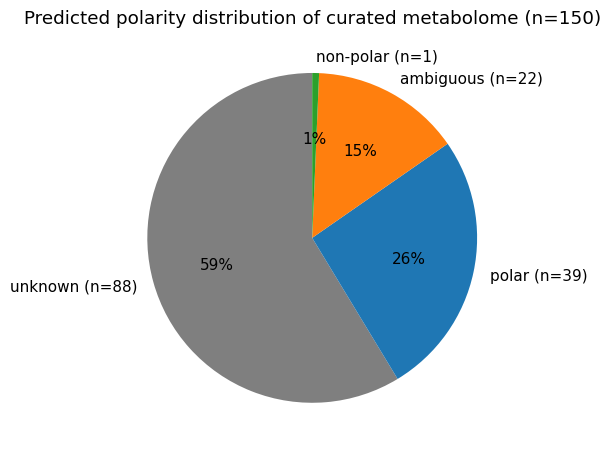

In [5]:
polarity_counts = df_metabolites['polarity'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    polarity_counts,
    labels=[f"{cat} (n={n})" for cat, n in polarity_counts.items()],
    autopct="%1.0f%%",
    colors=[POLARITY_COLORS.get(cat, "tab:gray") for cat in polarity_counts.index],
    startangle=90,
)
ax.set_title(f"Predicted polarity distribution of curated metabolome (n={len(df_metabolites)})")
plt.tight_layout()
plt.show()

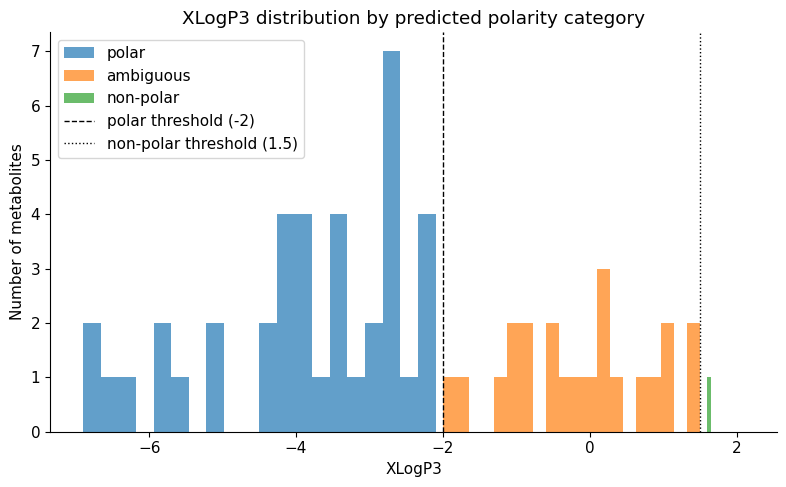

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for cat, color in POLARITY_COLORS.items():
    values = df_metabolites.loc[df_metabolites['polarity'] == cat, 'xlogp3'].dropna()
    if len(values):
        ax.hist(values, bins=20, alpha=0.7, label=cat, color=color)
ax.axvline(-2, color="black", linestyle="--", linewidth=1, label="polar threshold (-2)")
ax.axvline(1.5, color="black", linestyle=":", linewidth=1, label="non-polar threshold (1.5)")
ax.set_xlabel("XLogP3")
ax.set_ylabel("Number of metabolites")
ax.set_title("XLogP3 distribution by predicted polarity category")
ax.legend()
plt.tight_layout()
plt.savefig(f'figures/xlogp3_distribution_by_polarity.svg', dpi=300)
plt.show()

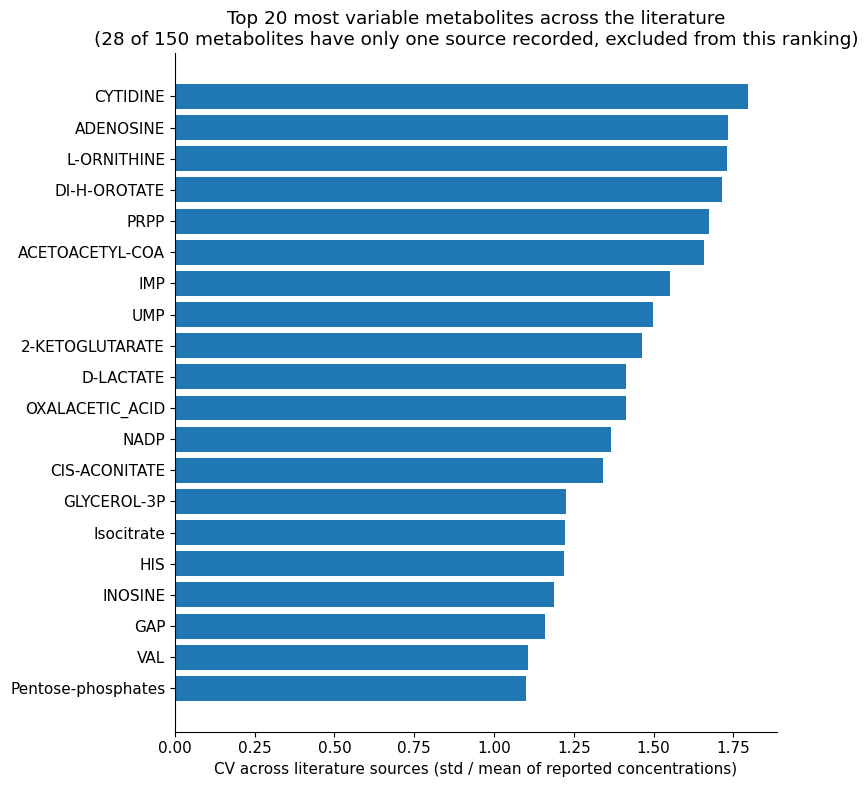

In [14]:
TOP_N = 20
ranked = (
    df_metabolites.dropna(subset=["cv_literature"])
    .sort_values("cv_literature", ascending=False)
    .head(TOP_N)
)
n_excluded = df_metabolites["cv_literature"].isna().sum()

fig, ax = plt.subplots(figsize=(8, 0.35 * len(ranked) + 1))
ax.barh(ranked["metabolites_biocyc"], ranked["cv_literature"], color="tab:blue")
ax.invert_yaxis()
ax.set_xlabel("CV across literature sources (std / mean of reported concentrations)")
ax.set_title(
    f"Top {len(ranked)} most variable metabolites across the literature\n"
    f"({n_excluded} of {len(df_metabolites)} metabolites have only one source "
    "recorded, excluded from this ranking)"
)
plt.tight_layout()
plt.savefig(f'figures/curated_high_cv_metabolites.svg', dpi=300)
plt.show()

/var/folders/s9/gn2yly0s7rzgcc2xyvt7nsxm0000gr/T/ipykernel_30002/1155459390.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


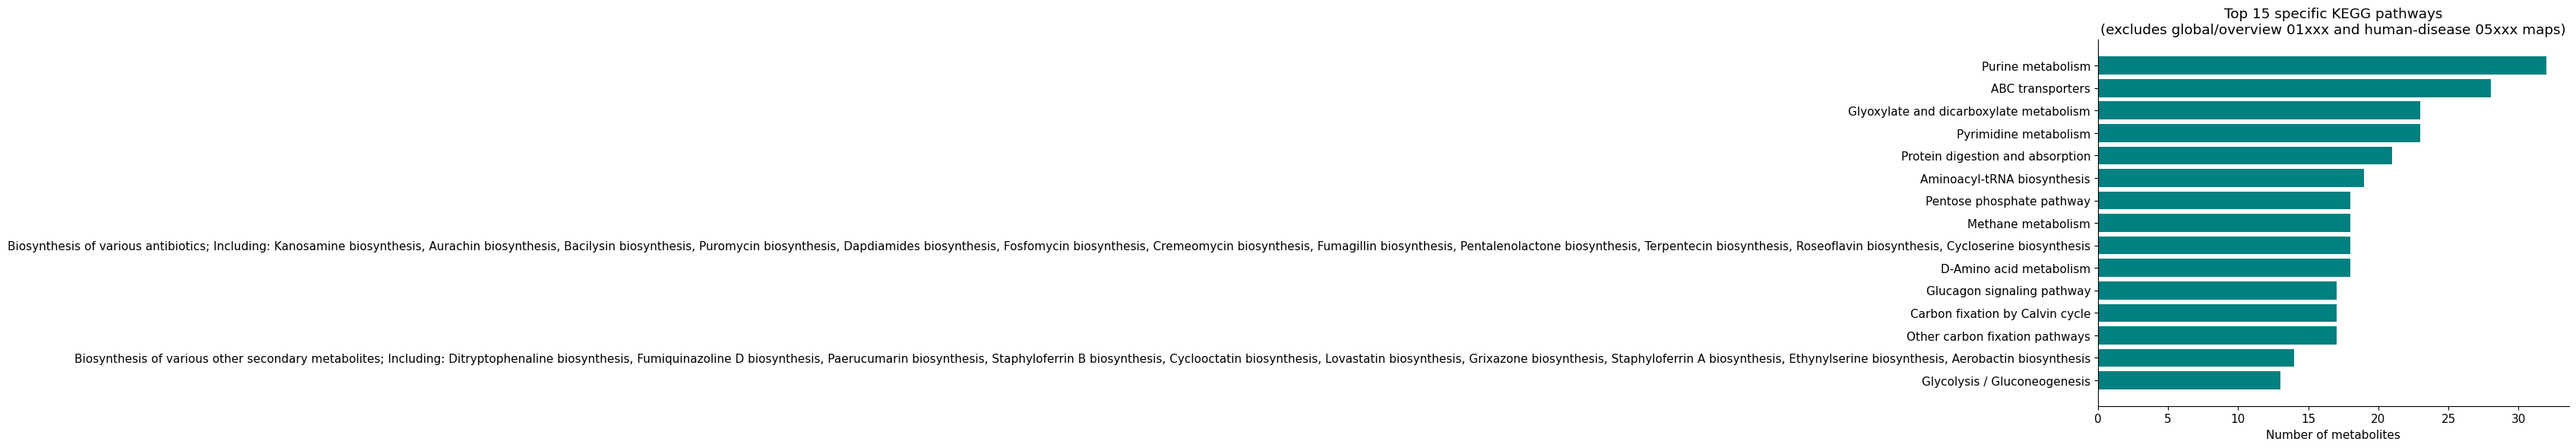

In [145]:
def parse_pathways(value):
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError, TypeError):
        return []

def is_overview_or_disease_map(map_id):
    # KEGG's own "Global and overview maps" (01xxx) and "Human Diseases"
    # (05xxx) categories link to nearly every compound and aren't specific
    # to this metabolite's actual metabolic role.
    return map_id.startswith("map01") or map_id.startswith("map05")

pathway_counts = Counter()
for value in df_metabolites["pathways_for_compound"].dropna():
    for map_id, name in parse_pathways(value):
        if not is_overview_or_disease_map(map_id):
            pathway_counts[name] += 1

TOP_N_PATHWAYS = 15
top_pathways = pathway_counts.most_common(TOP_N_PATHWAYS)
names, counts = zip(*top_pathways)

fig, ax = plt.subplots(figsize=(8, 0.35 * len(names) + 1))
ax.barh(names, counts, color="teal")
ax.invert_yaxis()
ax.set_xlabel("Number of metabolites")
ax.set_title(
    f"Top {len(names)} specific KEGG pathways\n"
    "(excludes global/overview 01xxx and human-disease 05xxx maps)"
)
plt.tight_layout()
plt.show()

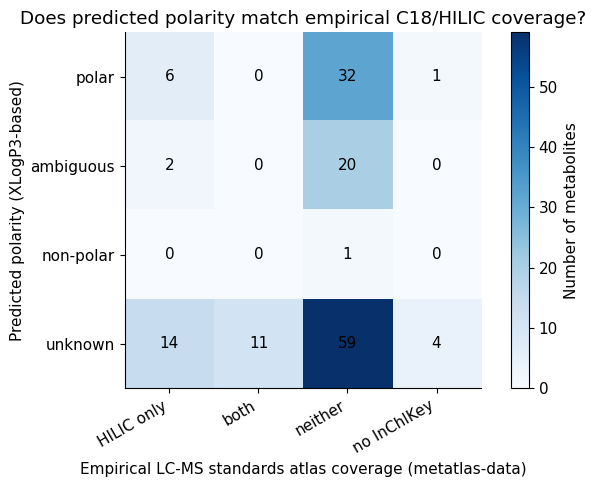

In [146]:
column_order = [c for c in ["HILIC only", "both", "C18 only", "neither", "no InChIKey"]
                if c in df_metabolites["lc_column_coverage"].unique()]
polarity_order = [p for p in ["polar", "ambiguous", "non-polar", "unknown"]
                   if p in df_metabolites["polarity"].unique()]

crosstab = pd.crosstab(df_metabolites["polarity"], df_metabolites["lc_column_coverage"])
crosstab = crosstab.loc[polarity_order, column_order]

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(crosstab.values, cmap="Blues")
ax.set_xticks(range(len(column_order)))
ax.set_xticklabels(column_order, rotation=30, ha="right")
ax.set_yticks(range(len(polarity_order)))
ax.set_yticklabels(polarity_order)
for i in range(len(polarity_order)):
    for j in range(len(column_order)):
        ax.text(j, i, crosstab.values[i, j], ha="center", va="center")
ax.set_xlabel("Empirical LC-MS standards atlas coverage (metatlas-data)")
ax.set_ylabel("Predicted polarity (XLogP3-based)")
ax.set_title("Does predicted polarity match empirical C18/HILIC coverage?")
fig.colorbar(im, ax=ax, label="Number of metabolites")
plt.tight_layout()
plt.show()